In [21]:
# Import required libraries

import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Load dataset

df = pd.read_csv("churn_data.csv")

print("Shape of dataset:", df.shape)

df.head()

Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Check missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# Check churn column values

print(df["Churn"].unique())

['No' 'Yes']


In [6]:
# Remove customer ID

df.drop("customerID", axis=1, inplace=True)

In [7]:
# Convert target into numeric

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].unique())

[0 1]


In [22]:
df = pd.get_dummies(df, drop_first=True)

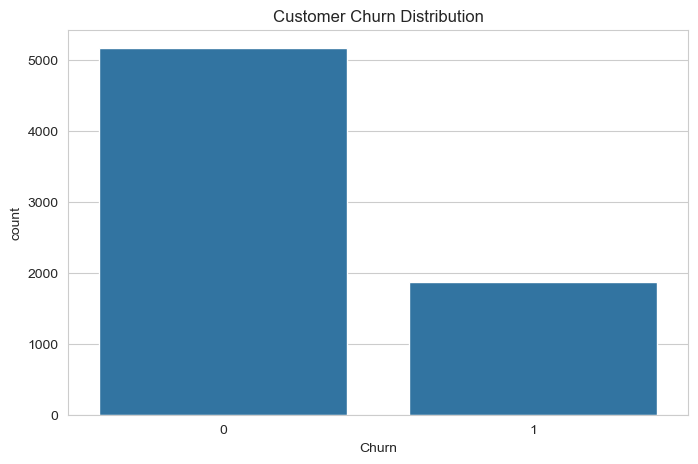

In [8]:
# Churn distribution

plt.figure(figsize=(8,5))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

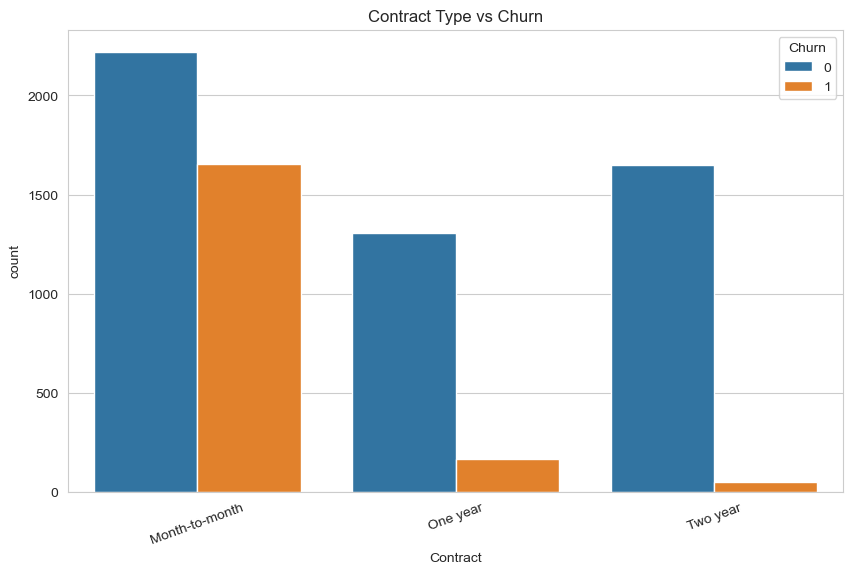

In [9]:
# Contract type vs churn

plt.figure(figsize=(10,6))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.title("Contract Type vs Churn")
plt.show()

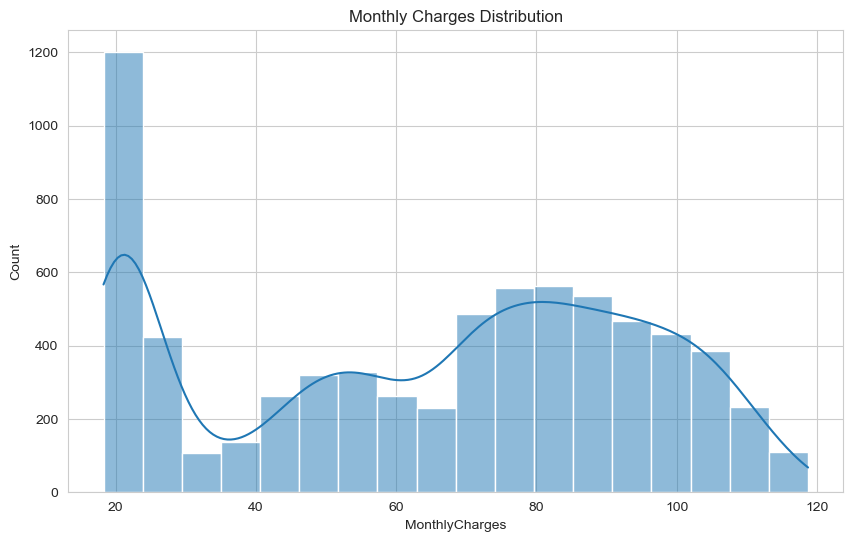

In [10]:
# Monthly charges distribution

plt.figure(figsize=(10,6))
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

In [11]:
# Convert categorical columns

df = pd.get_dummies(df, drop_first=True)

In [12]:
# Separate features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [13]:
# Split training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# Scale data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
import joblib

joblib.dump(rf, "churn_model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("Saved Successfully")
print("Columns:", len(X.columns))

Saved Successfully
Columns: 6559


In [27]:
cols = joblib.load("columns.pkl")
print(len(cols))

6559


In [15]:
# Import ML models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [16]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Accuracy: 0.7842441447835344


In [17]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.7700496806245565


In [18]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.8005677785663591


In [20]:
# Save best model

import joblib

joblib.dump(rf, "churn_model.pkl")
joblib.dump(X.columns, "columns.pkl")

print("Model saved successfully")

Model saved successfully


In [29]:
import joblib
import pandas as pd

model = joblib.load("churn_model.pkl")
cols = joblib.load("columns.pkl")

print("Model loaded")
print("No of features:", len(cols))

Model loaded
No of features: 6559


In [30]:
import numpy as np

# create dummy input (all zeros)
test_input = pd.DataFrame(np.zeros((1, len(cols))), columns=cols)

pred = model.predict(test_input)
print("Prediction on zero input:", pred)

Prediction on zero input: [0]


c:\Users\Brahm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [31]:
proba = model.predict_proba(test_input)
print("Probability [Stay, Churn]:", proba)

Probability [Stay, Churn]: [[0.88 0.12]]


c:\Users\Brahm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [32]:
churn_case = pd.DataFrame(np.zeros((1, len(cols))), columns=cols)

# simulate risky customer
if "tenure" in cols:
    churn_case["tenure"] = 1

if "MonthlyCharges" in cols:
    churn_case["MonthlyCharges"] = 100

if "TotalCharges" in cols:
    churn_case["TotalCharges"] = 100

if "SeniorCitizen" in cols:
    churn_case["SeniorCitizen"] = 1

# contract risky
for c in cols:
    if "Month-to-month" in c:
        churn_case[c] = 1

pred2 = model.predict(churn_case)
print("Churn case prediction:", pred2)
print("Probability:", model.predict_proba(churn_case))

Churn case prediction: [0]
Probability: [[0.77 0.23]]


c:\Users\Brahm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\Brahm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [33]:
# if you still have dataset
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [34]:
RandomForestClassifier(class_weight="balanced")

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")

In [38]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(X, y)

In [39]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

In [40]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.67      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [43]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [44]:
RandomForestClassifier(
    class_weight="balanced",
    max_depth=10,
    n_estimators=200
)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
proba = model.predict_proba(X_test)[:,1]
y_pred = (proba > 0.3).astype(int)

In [46]:
model = joblib.load("churn_model.pkl")

In [48]:
import pandas as pd
import numpy as np

input_data = pd.DataFrame(np.zeros((1, len(cols))), columns=cols)

In [49]:
if "tenure" in input_data.columns:
    input_data["tenure"] = 1

if "MonthlyCharges" in input_data.columns:
    input_data["MonthlyCharges"] = 100

if "TotalCharges" in input_data.columns:
    input_data["TotalCharges"] = 100

if "SeniorCitizen" in input_data.columns:
    input_data["SeniorCitizen"] = 1

In [50]:
proba = model.predict_proba(input_data)

print("Probability [Stay, Churn]:", proba)
print("Churn Risk %:", proba[0][1] * 100)

Probability [Stay, Churn]: [[0.77 0.23]]
Churn Risk %: 23.0


c:\Users\Brahm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [51]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
feature_columns = X.columns

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
import joblib

joblib.dump(model, "churn_model.pkl")
joblib.dump(feature_columns, "columns.pkl")

['columns.pkl']